In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
#load dataset
df = pd.read_csv('dataset.csv') 

In [3]:
# Cek data awal
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Cek missing value
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [5]:
#data cleaning
df = df.dropna()
df = df.drop(columns=['track_id', 'artists', 'album_name'], errors='ignore')

# 🔥 FIX PENTING (BIAR MATCH)
df['track_name'] = df['track_name'].astype(str).str.strip().str.lower()

In [6]:
# Tidak perlu filter genre, gunakan semua data
df = df.copy()

# Reset index
df = df.reset_index(drop=True)

# Cek hasil distirbusi
print(df['track_genre'].value_counts())


track_genre
acoustic             1000
afrobeat             1000
psych-rock           1000
progressive-house    1000
power-pop            1000
                     ... 
emo                  1000
electronic           1000
electro              1000
world-music          1000
k-pop                 999
Name: count, Length: 114, dtype: int64


In [7]:
#Fitur Selection
fitur = [
    'danceability','energy','loudness',
    'speechiness','acousticness',
    'instrumentalness','liveness',
    'valence','tempo'
]

In [8]:
#Encoding Genre
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

X = df[fitur]
y = df['genre_encoded']

In [9]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#Training RF
rf = RandomForestClassifier(

    n_estimators=500,

    max_depth=25,

    min_samples_split=5,

    min_samples_leaf=2,

    max_features='sqrt',

    class_weight='balanced',

    random_state=42,

    n_jobs=4

)

rf.fit(X_train, y_train)

df['predicted_genre'] = rf.predict(X)
df['predicted_genre_label'] = le.inverse_transform(df['predicted_genre'])

In [11]:
#Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=fitur, index=df.index)

In [12]:
#Rekomendasi
def rekomendasi_lagu(judul_lagu, top_n=5, use_filter=True):

    judul_lagu = str(judul_lagu).strip().lower()

    if judul_lagu not in set(df['track_name']):
        return "Lagu tidak ditemukan di dataset"

    idx = df[df['track_name'] == judul_lagu].index[0]

    genre = df.loc[idx, 'predicted_genre']

    if use_filter:
        df_filter = df[df['predicted_genre'] == genre]
        df_filter_scaled = df_scaled.loc[df_filter.index]
    else:
        df_filter = df
        df_filter_scaled = df_scaled

    sim = cosine_similarity([df_scaled.loc[idx]], df_filter_scaled)

    sim_scores = list(enumerate(sim[0]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:]

    hasil = []
    sudah_ada = set()

    for i in sim_scores:

        idx_lagu = df_filter.iloc[i[0]].name
        nama_lagu = df.loc[idx_lagu, 'track_name']

        if nama_lagu not in sudah_ada:

            hasil.append({
                'track_name': nama_lagu,
                'genre': df.loc[idx_lagu, 'predicted_genre_label'],
                'similarity': round(i[1], 4)
            })

            sudah_ada.add(nama_lagu)

        if len(hasil) == top_n:
            break

    return pd.DataFrame(hasil)

In [13]:
# evaluasi

def evaluasi_sistem(data):

    def eval_k(k):

        total_precision = 0
        total_recall = 0
        valid = 0

        for idx in range(len(data)):

            judul = data.iloc[idx]['track_name']

            rec = rekomendasi_lagu(
                judul,
                top_n=100,
                use_filter=True
            )

            if isinstance(rec, str):
                continue

            precision_k = rec.head(k)['similarity'].mean()

            total_similarity = rec['similarity'].sum()

            if total_similarity > 0:
                recall_k = (
                    rec.head(k)['similarity'].sum()
                    /
                    total_similarity
                )
            else:
                recall_k = 0

            total_precision += precision_k
            total_recall += recall_k

            valid += 1

        if valid == 0:
            return 0, 0

        avg_precision = total_precision / valid
        avg_recall = total_recall / valid

        return avg_precision, avg_recall

    # ======================
    # TOP 10
    # ======================
    p10, r10 = eval_k(10)

    # ======================
    # TOP 30
    # ======================
    p30, r30 = eval_k(30)

    # ======================
    # TOP 50
    # ======================
    p50, r50 = eval_k(50)

    print("=== Evaluasi Sistem Rekomendasi ===\n")

    print(f"Precision@10 : {p10:.4f}")
    print(f"Recall@10    : {r10:.4f}\n")

    print(f"Precision@30 : {p30:.4f}")
    print(f"Recall@30    : {r30:.4f}\n")

    print(f"Precision@50 : {p50:.4f}")
    print(f"Recall@50    : {r50:.4f}")

    # ======================
    # VISUALISASI
    # ======================

    import matplotlib.pyplot as plt
    import numpy as np

    labels = ['Top-10', 'Top-30', 'Top-50']

    precision = [p10, p30, p50]
    recall = [r10, r30, r50]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10,6))

    bar1 = plt.bar(
        x - width/2,
        precision,
        width,
        label='Precision'
    )

    bar2 = plt.bar(
        x + width/2,
        recall,
        width,
        label='Recall'
    )

    plt.ylabel('Skor Evaluasi')
    plt.xlabel('Evaluasi Top-K')
    plt.ylim(0,1)
    plt.xticks(x, labels)

    # Nilai di atas batang
    for bar in bar1:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f'{h:.3f}',
            ha='center'
        )

    for bar in bar2:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f'{h:.3f}',
            ha='center'
        )

    plt.legend()
    plt.title('Hasil Evaluasi Sistem Rekomendasi')
    plt.tight_layout()
    plt.show()

    return (
        p10, r10,
        p30, r30,
        p50, r50
    )

In [14]:
judul = "something in the way"

rec = rekomendasi_lagu(judul, top_n=100, use_filter=True)
print(rec)

                                           track_name   genre  similarity
0                                something in the way  grunge      1.0000
1                                        just breathe  grunge      0.9562
2                                       present tense  grunge      0.9533
3                                             release  grunge      0.9431
4                             black gives way to blue  grunge      0.9373
..                                                ...     ...         ...
95                                            haunted  grunge      0.7366
96                                  shelf in the room  grunge      0.7348
97  elderly woman behind the counter in a small to...  grunge      0.7333
98                                      ashes of eden  grunge      0.7330
99  nutshell - live at the majestic theatre, brook...  grunge      0.7324

[100 rows x 3 columns]


=== Evaluasi Sistem Rekomendasi ===

Precision@10 : 0.9913
Recall@10    : 0.1016

Precision@30 : 0.9861
Recall@30    : 0.3033

Precision@50 : 0.9826
Recall@50    : 0.5036


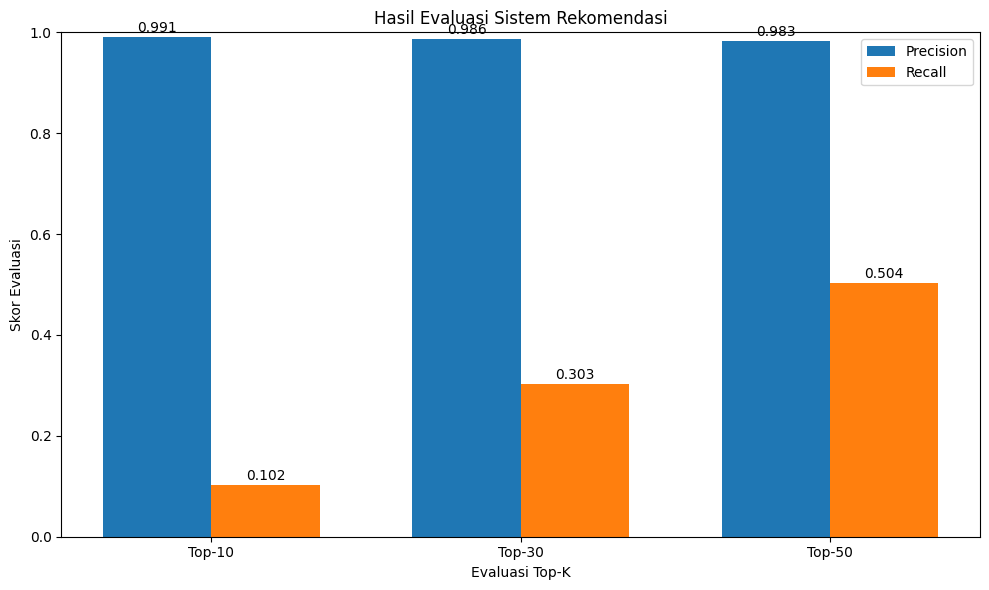

(np.float64(0.9912973838366967),
 np.float64(0.10163034513951437),
 np.float64(0.9860990599040332),
 np.float64(0.30325031854124235),
 np.float64(0.9825745994087888),
 np.float64(0.5035664164762528))

In [15]:
evaluasi_sistem(df)

=== Evaluasi Random Forest ===
Accuracy : 0.236
Precision: 0.227
Recall   : 0.236
F1-score : 0.225

Classification Report:

              precision    recall  f1-score   support

           0       0.14      0.13      0.14       213
           1       0.29      0.21      0.24       203
           2       0.05      0.04      0.04       215
           3       0.14      0.10      0.11       184
           4       0.25      0.21      0.23       197
           5       0.15      0.09      0.11       193
           6       0.35      0.41      0.38       210
           7       0.29      0.39      0.33       205
           8       0.17      0.14      0.15       214
           9       0.01      0.01      0.01       197
          10       0.27      0.21      0.24       199
          11       0.10      0.04      0.06       214
          12       0.19      0.23      0.21       193
          13       0.40      0.48      0.44       206
          14       0.35      0.29      0.31       214
          1

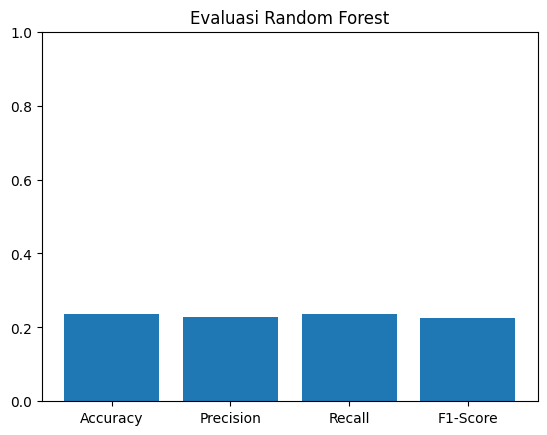

In [16]:
# =========================
# EVALUASI RANDOM FOREST
# =========================

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred, average='weighted')
recall_rf = recall_score(y_test, y_pred, average='weighted')
f1_rf = f1_score(y_test, y_pred, average='weighted')

print("=== Evaluasi Random Forest ===")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision_rf, 3))
print("Recall   :", round(recall_rf, 3))
print("F1-score :", round(f1_rf, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# VISUALISASI (OPSIONAL UNTUK SKRIPSI)
# =========================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision_rf, recall_rf, f1_rf]

plt.figure()
plt.bar(metrics, values)
plt.title("Evaluasi Random Forest")
plt.ylim(0, 1)
plt.show()